# Motion analysis

In this notebook, we analyze the motion of the cellular system.

Because the simulations use periodic boundary conditions, the continuous cell trajectories are reconstructed by unwrapping the positions using the minimum-image displacement between consecutive simulation steps.

We first consider the cumulative mean squared displacement relative to the initial configuration,

$$
\mathrm{MSD}_{t_0}(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
\tilde{\mathbf r}_i(t)
-
\tilde{\mathbf r}_i(0)
\right|^2.
$$

This quantity measures how far, on average, the cells have moved from their initial positions.

We then use instantaneous one-step displacement observables to characterize how the cellular mobility itself develops during the evolution.

## Import libraries


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load and inspect data

In [2]:
DATA_DIR = "data/motion"

motion = pd.read_parquet(
    f"{DATA_DIR}/motion.parquet"
)

motion.head()

,N,reference_N,actual_N,rho,actual_rho,seed,step,initial_fraction_elongated,force,mean_step_displacement,mean_squared_step_displacement,p95_step_displacement,msd_t0
0,10000,10152,9000,0.8,0.799975,12944511869278,0,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.000000,0.000000,0.000000,0.000000
1,10000,10152,9000,0.8,0.799975,12944511869278,100,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.033336,0.001344,0.057689,0.052606
2,10000,10152,9000,0.8,0.799975,12944511869278,200,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.030388,0.001151,0.055428,0.176742
3,10000,10152,9000,0.8,0.799975,12944511869278,300,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.028280,0.001201,0.053652,0.406238
4,10000,10152,9000,0.8,0.799975,12944511869278,400,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.027570,0.001159,0.053205,0.802248


In [3]:
print("Shape:", motion.shape)

print("\nColumns:")
print(motion.columns.tolist())

print("\nN:")
print(sorted(motion["N"].unique()))

print("\nDensities:")
print(sorted(motion["rho"].unique()))

print("\nSeeds per density:")
print(
    motion.groupby("rho")["seed"].nunique()
)

print("\nStep range:")
print(
    motion["step"].min(),
    motion["step"].max(),
    motion["step"].nunique(),
)

Shape: (185693, 13)

Columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'mean_step_displacement', 'mean_squared_step_displacement', 'p95_step_displacement', 'msd_t0']

N:
[np.int64(10000)]

Densities:
[np.float64(0.8), np.float64(0.81), np.float64(0.82), np.float64(0.83), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.87)]

Seeds per density:
rho
0.80    32
0.81    32
0.82    32
0.83    32
0.84    32
0.85    32
0.86    32
0.87    32
Name: seed, dtype: int64

Step range:
0 80000 801


In [4]:
motion.groupby(
    ["rho", "seed"]
)["step"].agg(
    ["min", "max", "count"]
).describe()

,min,max,count
count,256.0,256.000000,256.000000
mean,0.0,72436.328125,725.363281
std,0.0,4084.947091,40.849471
min,0.0,68200.000000,683.000000
25%,0.0,69900.000000,700.000000
50%,0.0,70600.000000,707.000000
75%,0.0,71725.000000,718.250000
max,0.0,80000.000000,801.000000


## Cumulative displacement

### Mean squared displacement

We first study the mean squared displacement from the initial configuration as a function of time.

For each density, $\mathrm{MSD}_{t_0}$ is averaged over independent realizations at fixed simulation step.

Since the displacement is always measured relative to the initial configuration, this observable retains the complete history of the system. It should therefore not be interpreted as a stationary lag-time MSD averaged over different time origins.

In [5]:
# Take the mean and std of the MSD for each density and step
msd_time = (
    motion
    .groupby(["rho", "step"])
    .agg(
        msd_mean=("msd_t0", "mean"),
        msd_std=("msd_t0", "std"),
        number_of_seeds=("seed", "nunique"),
    )
    .reset_index()
)

msd_time.head()

,rho,step,msd_mean,msd_std,number_of_seeds
0,0.8,0,0.000000,0.000000,32
1,0.8,100,0.050317,0.011292,32
2,0.8,200,0.169929,0.032697,32
3,0.8,300,0.377082,0.072756,32
4,0.8,400,0.716795,0.142951,32


In [6]:
densities = sorted(msd_time["rho"].unique())

cmap = plt.cm.viridis
norm = plt.Normalize(
    min(densities),
    max(densities),
)

### Local growth exponent

To characterize changes in the growth of the cumulative displacement, we calculate the local logarithmic slope

$$
\alpha(t)
=
\frac{d\log \mathrm{MSD}_{t_0}(t)}
{d\log t}.
$$

The values $\alpha=1$ and $\alpha=2$ provide useful references for diffusive-like and ballistic-like growth, respectively.

However, the system is not stationary throughout the evolution. It starts from an initially round and passive configuration and develops an active elongated population over time.

In [7]:
# Compute the local growth exponent for each density
alpha_data = []

for rho in densities:

    # Filter the MSD data for the current density
    df_rho = msd_time[
        np.isclose(msd_time["rho"], rho)
    ].copy()

    df_rho = df_rho[
        (df_rho["step"] > 0)
        & (df_rho["msd_mean"] > 0)
    ]

    # Compute the local growth exponent alpha(t) = d(log(MSD))/d(log(t))
    t = df_rho["step"].to_numpy()
    msd = df_rho["msd_mean"].to_numpy()

    log_t = np.log(t)
    log_msd = np.log(msd)
    # Compute the gradient of log(MSD) with respect to log(t)
    alpha = np.gradient(
        log_msd,
        log_t,
    )

    # Smooth the alpha(t) data using a moving average with a window size of 5
    window_size = 5

    if len(alpha) > window_size:

        kernel = (
            np.ones(window_size)
            / window_size
        )

        alpha_smooth = np.convolve(
            alpha,
            kernel,
            mode="valid",
        )

        half_window = window_size // 2

        t_smooth = t[
            half_window:
            -half_window
        ]

    else:
        alpha_smooth = alpha
        t_smooth = t

    alpha_data.append(
        pd.DataFrame(
            {
                "rho": rho,
                "step": t_smooth,
                "alpha": alpha_smooth,
            }
        )
    )

# Concatenate the alpha(t) data for all densities into a single DataFrame
alpha_time = pd.concat(
    alpha_data,
    ignore_index=True,
)

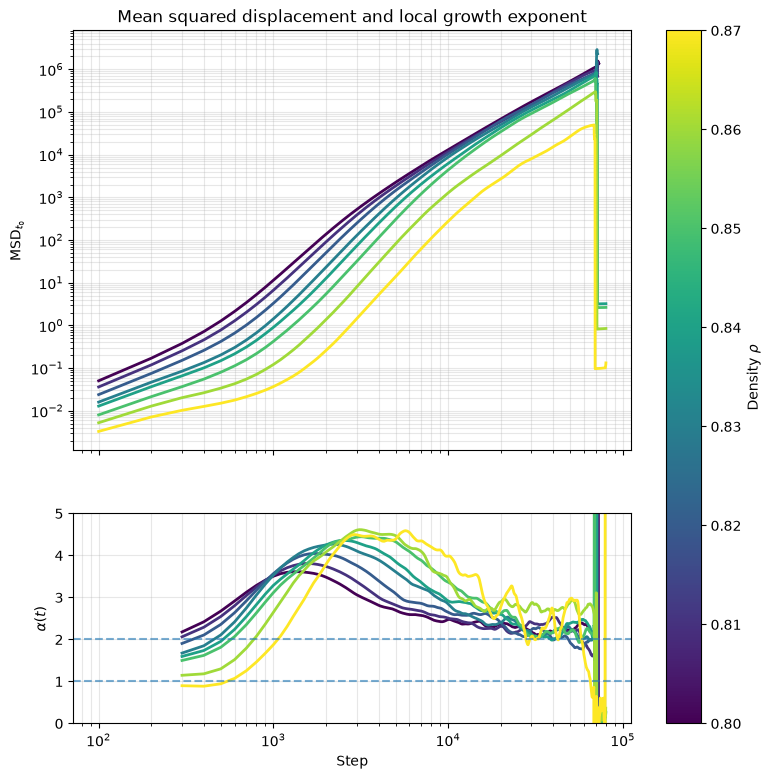

In [8]:
# Create a color map for the densities
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(9, 9),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1],
    },
)

# For each density, plot the MSD and alpha(t) on the respective axes
for rho in densities:

    color = cmap(norm(rho))

    df_msd = msd_time[
        np.isclose(msd_time["rho"], rho)
    ]

    df_msd = df_msd[
        (df_msd["step"] > 0)
        & (df_msd["msd_mean"] > 0)
    ]

    ax1.plot(
        df_msd["step"],
        df_msd["msd_mean"],
        linewidth=2,
        color=color,
    )

    df_alpha = alpha_time[
        np.isclose(alpha_time["rho"], rho)
    ]

    ax2.plot(
        df_alpha["step"],
        df_alpha["alpha"],
        linewidth=2,
        color=color,
    )


ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_ylabel(
    r"$\mathrm{MSD}_{t_0}$"
)

ax1.set_title(
    "Mean squared displacement and local growth exponent"
)

ax1.grid(
    alpha=0.3,
    which="both",
)


ax2.set_xscale("log")

ax2.set_xlabel("Step")
ax2.set_ylabel(r"$\alpha(t)$")

ax2.set_ylim(0, 5)
ax2.axhline(
    1,
    linestyle="--",
    alpha=0.6,
)

ax2.axhline(
    2,
    linestyle="--",
    alpha=0.6,
)

ax2.grid(
    alpha=0.3,
    which="both",
)


sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)

cbar = fig.colorbar(
    sm,
    ax=[ax1, ax2],
)

cbar.set_label(r"Density $\rho$")

folder_name = "figures/motion"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

graph_title = (
    "Mean squared displacement "
    "and local growth exponent"
)

rout_title = (
    graph_title
    .lower()
    .replace(" ", "_")
)

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The cumulative displacement depends strongly on density. At a given time, lower-density systems explore much larger distances, while the motion becomes progressively suppressed as density increases.

The local growth exponent shows a pronounced transient increase above the ballistic reference value $\alpha=2$. Since the system starts from an initially round and passive configuration, this superquadratic growth it is consistent with a transient acceleration while the active elongated population develops.

As the evolution continues, $\alpha(t)$ decreases towards values close to $2$. This suggests approximately ballistic-like growth over the late-time window explored here, consistent with persistent collective motion in the active state.

The maximum of $\alpha(t)$ also appears to shift towards later times as density increases. One possible interpretation is that the development of the active elongated population becomes progressively delayed at higher densities.